# Klasifikasi Ulos Menggunakan MobileNetV2 dengan Stratified Grouped Split & Fine-Tuning Ringan

Notebook ini merupakan revisi metodologis untuk klasifikasi 14 kelas ulos dengan pembagian data **80% training dan 20% testing**, ditambah **validation internal (10% dari training)**.

### Karakteristik & Tujuan Utama Revisi:
1. **Pemberantasan Kebocoran Data (Data Leakage-Free):** Menggunakan **Stratified Grouped Split** berdasarkan `image_group` (ID kain asal). Semua gambar hasil augmentasi/cropping yang berasal dari satu kain fisik yang sama dijamin masuk ke subset yang sama (seluruhnya di train, val, atau test). Hal ini mencegah overfitting semu dan menghasilkan evaluasi ilmiah yang valid untuk sidang/karya tulis ilmiah.
2. **Hyperparameter yang Seimbang (Regularized):** Menggunakan unfreeze layer (`UNFREEZE_LAST_N = 40`) dan densitas classifier head (`dense_units` 256/384) yang teratur untuk menghindari overfitting pada dataset berukuran sedang (~1410 training images).
3. **Penyetelan Otomatis Ringan (Light Tuning):** Mencari kombinasi learning rate, dropout, dan dense units terbaik secara otomatis sebelum training final.
4. **Kalibrasi Django Terintegrasi:** Menyertakan aturan threshold penolakan objek bukan ulos (skor <= 0.40) dan kepastian ulos terdeteksi (skor >= 0.71) untuk diintegrasikan dengan sistem web Django.


## 1. Environment & Import Library
Bagian ini digunakan untuk menyiapkan library yang dibutuhkan seperti TensorFlow/Keras untuk deep learning, scikit-learn untuk metrik evaluasi dan pembagian data, serta pandas/numpy untuk pemrosesan data.
* **Force CPU Mode:** Diaktifkan (`FORCE_CPU = True`) untuk memastikan kestabilan eksekusi di lingkungan lokal yang tidak memiliki CUDA/CuDNN kompatibel.


In [1]:

# ============================================
# 1. ENVIRONMENT & IMPORT
# ============================================
import os

# Paksa CPU agar stabil di environment yang sebelumnya bermasalah dengan CUDA/CuDNN
FORCE_CPU = True
GPU_INDEX = "0"

if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = GPU_INDEX

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import sys
import io
import json
import math
import time
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

if FORCE_CPU:
    try:
        tf.config.set_visible_devices([], "GPU")
    except Exception:
        pass

print("TensorFlow version:", tf.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))
print("FORCE_CPU:", FORCE_CPU)


2026-06-10 03:39:50.585967: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-10 03:39:50.585990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-10 03:39:50.586765: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.15.0
Visible GPUs: []
FORCE_CPU: True


2026-06-10 03:39:52.041487: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### 📊 Analisis & Arti Output - Cell 1 (Environment Setup):
* **TensorFlow version: 2.15.0**: Menunjukkan Keras/TensorFlow versi 2.15.0 telah berhasil dimuat.
* **Visible GPUs: [] & FORCE_CPU: True**: Mengonfirmasi bahwa model dipaksa berjalan pada **CPU** (`FORCE_CPU = True`).
* **Peringatan CUDA/cuDNN (Baris E...):** Pesan eror ini wajar terjadi karena sistem mendeteksi ketidakcocokan driver GPU lokal (tidak ada device CUDA yang terdeteksi), sehingga TensorFlow secara otomatis beralih menggunakan CPU secara aman tanpa membuat program terhenti.


## 2. Konfigurasi Utama & Hyperparameter
Pada bagian ini, parameter utama pelatihan dikonfigurasi:
* **Dimensi Input:** Gambar diubah menjadi `224x224` piksel agar selaras dengan arsitektur MobileNetV2 pre-trained ImageNet.
* **Rasio Data:** 80% pelatihan (`TRAIN_RATIO = 0.80`), 20% pengujian (`TEST_RATIO = 0.20`), dan 10% dari data pelatihan diambil sebagai validation internal (`VAL_FROM_TRAIN_RATIO = 0.10`).
* **Regulasi Overfitting:**
  - `UNFREEZE_LAST_N = 40`: Hanya melatih kembali 40 layer teratas dari MobileNetV2 (base model) untuk mencegah perusakan fitur dasar ImageNet dan menghindari overfitting.
  - `dense_units = 256` atau `384` dalam `TUNING_CONFIGS` digunakan untuk membatasi kapasitas classifier head agar model fokus pada fitur umum ulos.


In [2]:
# ============================================
# 2. KONFIGURASI UTAMA
# ============================================
CSV_PATH = "/home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/_classes.csv"
IMAGE_DIR = "/home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2"
EXPORT_DIR = os.path.join(IMAGE_DIR, "cnn_training_artifacts_80_20_optimized")

SEED = 123
TRAIN_RATIO = 0.80
TEST_RATIO = 0.20
VAL_FROM_TRAIN_RATIO = 0.10   # 10% dari train 80% -> total ~8% data

# Menggunakan 224x224 agar selaras dengan pretrained MobileNetV2 ImageNet
IMG_HEIGHT, IMG_WIDTH = 224, 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
CHANNELS = 3
BATCH_SIZE = 16 if FORCE_CPU else 32

# Optimasi pipeline
CACHE_DATASET = True
USE_ANTIALIAS_RESIZE = True

# Tahap training (REGULARIZED/BALANCED HYPERPARAMETERS)
HEAD_EPOCHS = 25
TUNING_EPOCHS = 8
FINE_TUNE_EPOCHS = 15
UNFREEZE_LAST_N = 40
FINE_TUNE_LR = 1e-5

# Tuning ringan
RUN_LIGHT_TUNING = True
RUN_FINE_TUNING = True

# Konfigurasi kandidat dengan regularisasi lebih ketat untuk mencegah overfitting
TUNING_CONFIGS = [
    {"name": "cfg_1", "learning_rate": 1e-3, "dropout_rate": 0.35, "dense_units": 256},
    {"name": "cfg_2", "learning_rate": 7e-4, "dropout_rate": 0.35, "dense_units": 256},
    {"name": "cfg_3", "learning_rate": 5e-4, "dropout_rate": 0.40, "dense_units": 384},
]

DEFAULT_CONFIG = TUNING_CONFIGS[0]

# Paths artefak
os.makedirs(EXPORT_DIR, exist_ok=True)
BEST_STAGE1_PATH = os.path.join(EXPORT_DIR, "ulos_stage1_best.h5")
BEST_STAGE2_PATH = os.path.join(EXPORT_DIR, "ulos_stage2_best.h5")
FINAL_MODEL_PATH = os.path.join(EXPORT_DIR, "ulos_final_model.h5")
FINAL_H5_PATH = os.path.join(EXPORT_DIR, "ulos_final_model.h5")
LABELS_JSON_PATH = os.path.join(EXPORT_DIR, "class_names.json")
METRICS_JSON_PATH = os.path.join(EXPORT_DIR, "metrics_summary.json")
INFERENCE_JSON_PATH = os.path.join(EXPORT_DIR, "inference_config.json")
TUNING_CSV_PATH = os.path.join(EXPORT_DIR, "light_tuning_results.csv")
HEAD_HISTORY_CSV_PATH = os.path.join(EXPORT_DIR, "history_stage1.csv")
FINE_HISTORY_CSV_PATH = os.path.join(EXPORT_DIR, "history_stage2.csv")
EXTERNAL_INFERENCE_CSV_PATH = os.path.join(EXPORT_DIR, "external_folder_inference.csv")

print("Export dir:", EXPORT_DIR)
print("Image size:", IMG_SIZE)
# Hapus file model lama agar tidak menimpa model yang sudah ada sebelumnya
for filename in ["ulos_stage1_best.keras", "ulos_stage1_best.h5", 
                 "ulos_stage2_best.keras", "ulos_stage2_best.h5", 
                 "ulos_final_model.keras", "ulos_final_model.h5", 
                 "ulos_final_model.tflite"]:
    file_path = os.path.join(EXPORT_DIR, filename)
    if os.path.exists(file_path):
        try:
            os.remove(file_path)
            print(f"File model lama dihapus: {filename}")
        except Exception as e:
            print(f"Gagal menghapus {filename}: {str(e)}")


Export dir: /home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/cnn_training_artifacts_80_20_optimized
Image size: (224, 224)
File model lama dihapus: ulos_stage1_best.h5
File model lama dihapus: ulos_stage2_best.h5
File model lama dihapus: ulos_final_model.h5


### 📊 Analisis & Arti Output - Cell 2 (Konfigurasi Utama):
* **Export dir:** Menunjukkan lokasi absolut folder penyimpanan hasil latihan (`cnn_training_artifacts_80_20_optimized`).
* **Image size: (224, 224):** Mengonfirmasi ukuran gambar input.
* **Log Hapus File Model Lama:** Menunjukkan file model lama (`ulos_stage1_best.h5`, dll.) berhasil dihapus sebelum latihan baru dimulai. Hal ini memastikan bahwa file bobot model `.h5` yang akan dihasilkan nanti adalah murni dari proses training kali ini (tidak tertimpa atau menggunakan file lama).


## 3. Seed Kontrol Reproduksibilitas
Pengaturan random seed (`SEED = 123`) dilakukan pada tingkat Python, NumPy, dan TensorFlow untuk menjamin bahwa proses inisialisasi bobot dan pengacakan data bersifat konsisten/dapat diulang dengan hasil yang identik.


In [3]:

# ============================================
# 3. SEED
# ============================================
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.optimizer.set_jit(False)

print("Seed siap.")


Seed siap.


### 📊 Analisis & Arti Output - Cell 3 (Seed Reproduksibilitas):
* **Seed siap.** Output ini mengonfirmasi bahwa random seed generator untuk TensorFlow, NumPy, dan Python Random telah sukses dikunci ke angka `123`. Hal ini menjamin pembagian data dan inisialisasi bobot saraf tiruan akan selalu sama setiap kali notebook ini dijalankan ulang.


## 4. Memuat CSV & Standardisasi Label Ulos
Langkah ini memuat berkas metadata gambar `_classes.csv` dan mengonversi format label one-hot menjadi label kelas tunggal terenkode.
* **Standardisasi Nama Kelas:** Menyelaraskan nama-nama kelas yang tidak konsisten (misalnya 'Pinussaan' menjadi 'Pinuncaan', 'Suri Suri' menjadi 'Suri-Suri').
* **Pembersihan File:** Baris data dibersihkan apabila berkas gambarnya tidak ditemukan secara fisik di folder dataset.
* **Ekstraksi Group ID (`image_group`):** Menggunakan regex untuk mengekstrak nama dasar file (sebelum `.rf.`) sebagai ID grup asal. Ini adalah kunci penting dalam implementasi Grouped Split untuk mencegah data leakage.


In [4]:
# ============================================
# 4. LOAD CSV & STANDARISASI LABEL
# VERSI FIX: dukung kolom label eksplisit ATAU one-hot _classes.csv
# ============================================
if not os.path.exists(CSV_PATH) or not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError("CSV_PATH atau IMAGE_DIR tidak ditemukan.")

df = pd.read_csv(CSV_PATH)

# Rapikan kolom aneh seperti 'Unnamed: 0'
df = df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed", case=False, regex=True)].copy()

print("Kolom pada CSV:", df.columns.tolist())

# -----------------------------
# 1) Deteksi kolom filename
# -----------------------------
candidate_filename_cols = [
    c for c in df.columns
    if c.lower().strip() in ["filename", "file", "image", "images", "name"]
]

if candidate_filename_cols:
    filename_col = candidate_filename_cols[0]
else:
    # fallback: pakai kolom pertama
    filename_col = df.columns[0]

df[filename_col] = df[filename_col].astype(str).str.strip()

# Bangun path file
df["image_path"] = df[filename_col].apply(lambda x: os.path.join(IMAGE_DIR, x))
missing_count = (~df["image_path"].apply(os.path.exists)).sum()

if missing_count > 0:
    print(f"Peringatan: ada {missing_count} file gambar yang tidak ditemukan dari total {len(df)}")

# -----------------------------
# 2) Coba deteksi label eksplisit
# -----------------------------
candidate_label_cols = [
    c for c in df.columns
    if ("class" in c.lower()) or ("label" in c.lower())
]

label_col = None
for col in candidate_label_cols:
    if col == filename_col:
        continue
    if df[col].dtype == "object":
        label_col = col
        break

# -----------------------------
# 3) Jika tidak ada label eksplisit,
#    baca sebagai one-hot class columns
# -----------------------------
if label_col is not None:
    print(f"Menggunakan kolom label eksplisit: {label_col}")
    df["label_final"] = df[label_col].astype(str).str.strip()

else:
    # semua kolom selain filename dianggap kandidat kelas
    possible_class_cols = [c for c in df.columns if c not in [filename_col, "image_path"]]

    # pilih kolom numerik / boolean
    onehot_cols = []
    for c in possible_class_cols:
        series_num = pd.to_numeric(df[c], errors="coerce")
        unique_vals = set(series_num.dropna().unique().tolist())

        # anggap valid jika isinya hanya 0/1
        if len(unique_vals) > 0 and unique_vals.issubset({0, 1}):
            onehot_cols.append(c)

    if len(onehot_cols) == 0:
        raise ValueError(
            "Kolom label tidak ditemukan, dan tidak ada kolom one-hot 0/1 yang bisa dipakai sebagai kelas.\n"
            f"Kolom yang tersedia: {df.columns.tolist()}"
        )

    print("Menggunakan format one-hot class columns:")
    print(onehot_cols)

    # validasi: idealnya setiap baris hanya punya satu kelas = 1
    row_sum = df[onehot_cols].sum(axis=1)
    bad_rows = (row_sum != 1).sum()

    if bad_rows > 0:
        print(f"Peringatan: ada {bad_rows} baris yang jumlah label one-hot-nya bukan 1.")
        print("Baris-baris ini tetap akan diproses dengan memilih kolom bernilai maksimum.")

    df["label_final"] = df[onehot_cols].idxmax(axis=1).astype(str).str.strip()

# -----------------------------
# 4) Encode label & Standardisasi Nama Label
# -----------------------------
LABEL_MAPPING = {
    "Pinussaan": "Pinuncaan",
    "Suri Suri": "Suri-Suri",
    "Runjak": "Runjat",
    "Pina Lobu Lobu": "Pinan Lobu-Lobu",
    "Antak Antak": "Antak-antak",
    "Marinjam Sisi": "Simarinjam Sisi"
}
df["label_final"] = df["label_final"].replace(LABEL_MAPPING)

CLASS_NAMES = sorted(df["label_final"].dropna().unique().tolist())
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label_encoded"] = df["label_final"].map(class_to_idx).astype("int32")

# Buang file yang path-nya tidak ada
before_len = len(df)
df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

# -----------------------------
# 5) Ekstrak Group ID untuk Grouped Split (Mencegah Data Leakage)
# -----------------------------
import re
def get_original_image_id(filename):
    base = filename.split('.rf.')[0]
    base = re.sub(r'(_jpg|_png|_jpeg|_bmp|-f|_f|_aug)+$', '', base)
    return base

df["image_group"] = df[filename_col].apply(get_original_image_id)
after_len = len(df)

if after_len < before_len:
    print(f"{before_len - after_len} baris dibuang karena file gambar tidak ditemukan.")

print("Jumlah data total:", len(df))
print("Jumlah kelas:", len(CLASS_NAMES))
print("Contoh data:")
display(df[[filename_col, "label_final", "label_encoded"]].head())

print("Distribusi kelas:")
display(df["label_final"].value_counts().sort_index().to_frame("count"))

Kolom pada CSV: ['filename', 'Antak Antak', 'Bintang Maratur', 'Harungguan', 'Mangiring', 'Marinjam Sisi', 'Pina Lobu Lobu', 'Pinussaan', 'Ragi Hidup', 'Ragi Hotang', 'Runjak', 'Sadum', 'Sibolang', 'Sitolu Tuho', 'Suri Suri']
Menggunakan format one-hot class columns:
['Antak Antak', 'Bintang Maratur', 'Harungguan', 'Mangiring', 'Marinjam Sisi', 'Pina Lobu Lobu', 'Pinussaan', 'Ragi Hidup', 'Ragi Hotang', 'Runjak', 'Sadum', 'Sibolang', 'Sitolu Tuho', 'Suri Suri']
Jumlah data total: 1950
Jumlah kelas: 14
Contoh data:


,filename,label_final,label_encoded
0,Harungguan-5-_jpg.rf.737ab9f55694b3f8a2d88e559...,Harungguan,2
1,ragihotang-10-f_jpg.rf.d8605ae76cbde4c419d57cf...,Ragi Hotang,7
2,Pinunsaan-9-_jpg.rf.61c63fea1a9fff39043d65d858...,Pinuncaan,5
3,sadum-25-f_jpg.rf.2cef9af13040b55315dccdadfe41...,Sadum,9
4,Sadum-Angkola-6-_jpg.rf.03ee266574a015be8786aa...,Sadum,9


Distribusi kelas:


,count
label_final,
Antak-antak,70
Bintang Maratur,200
Harungguan,200
Mangiring,200
Pinan Lobu-Lobu,50
Pinuncaan,200
Ragi Hidup,200
Ragi Hotang,200
Runjat,40


### 📊 Analisis & Arti Output - Cell 4 (Muat Dataset & Label):
* **Kolom pada CSV:** Daftar kolom representasi one-hot untuk 14 kelas ulos yang dibaca dari file `_classes.csv`.
* **Jumlah data total: 1950:** Dataset Anda memiliki total **1950 file gambar** yang valid.
* **Jumlah kelas: 14:** Mengonfirmasi terdapat 14 jenis ulos yang berbeda.
* **Contoh Data (Tabel Pertama):** Menampilkan contoh 5 baris pertama setelah nama file diselaraskan dengan nama label aslinya.
* **Distribusi Kelas (Tabel Kedua):** Menampilkan jumlah gambar per kelas. Terlihat adanya **Ketidakseimbangan Kelas (Class Imbalance)**, di mana kelas mayoritas memiliki 200 gambar (misal Harungguan, Ragi Hidup, Ragi Hotang, dll.), sedangkan kelas minoritas memiliki jumlah gambar yang sedikit (seperti Runjat hanya 40 gambar, Pinan Lobu-Lobu hanya 50 gambar, dll.). Informasi ketidakseimbangan ini sangat krusial untuk dipahami sebelum model dilatih.


## 5. Pembagian Data (Stratified Grouped Split)
Untuk memastikan tidak terjadi kebocoran data (data leakage), data dibagi berdasarkan kelompok kain asal (`image_group`):
* **Backtracking Solver:** Digunakan untuk mencari kombinasi pembagian kelompok secara eksak agar didapatkan jumlah gambar yang presisi sesuai target dokumen (390 gambar untuk Test, 150 gambar untuk Validation, dan 1410 gambar untuk Training).
* **Bebas Leakage:** Semua variasi/augmentasi dari satu kain yang sama akan selalu berada dalam kelompok subset yang sama. Hal ini menjamin bahwa performa pengujian mencerminkan kemampuan generalisasi model sesungguhnya terhadap kain baru.


In [5]:
# ============================================
# 5. SPLIT 80/20 + VALIDATION INTERNAL (VERSI STRATIFIED GROUPED SPLIT DENGAN JUMLAH DATA PERSIS)
# ============================================
import random
import re

group_df = df.groupby("image_group").first().reset_index()

# Kumpulkan grup berdasarkan kelas
groups_by_class = {}
for _, row in group_df.iterrows():
    c = row["label_encoded"]
    g = row["image_group"]
    if c not in groups_by_class:
        groups_by_class[c] = []
    groups_by_class[c].append(g)

train_groups = []
val_groups = []
test_groups = []

# Distribusi grup secara acak namun terjamin representasinya di setiap split
rng = random.Random(SEED)
class_remaining_groups = {}

# Map group to its label and size
group_to_label = dict(zip(group_df["image_group"], group_df["label_encoded"]))
group_sizes = df["image_group"].value_counts().to_dict()

# 1. Alokasi minimal untuk menjamin representasi kelas
for c in sorted(groups_by_class.keys()):
    c_groups = list(groups_by_class[c])
    rng.shuffle(c_groups)
    
    if len(c_groups) == 1:
        train_groups.append(c_groups[0])
        class_remaining_groups[c] = []
    elif len(c_groups) == 2:
        train_groups.append(c_groups[0])
        test_groups.append(c_groups[1])
        class_remaining_groups[c] = []
    else:
        train_groups.append(c_groups[0])
        val_groups.append(c_groups[1])
        test_groups.append(c_groups[2])
        class_remaining_groups[c] = c_groups[3:]

# Hitung jumlah gambar saat ini di test dan val
current_test_size = sum(group_sizes[g] for g in test_groups)
current_val_size = sum(group_sizes[g] for g in val_groups)

# Target sisa gambar yang perlu diisi dari pool
t_test = 390 - current_test_size
t_val = 150 - current_val_size

# Kumpulkan semua sisa kelompok ke dalam pool
pool = []
for c in sorted(class_remaining_groups.keys()):
    for g in class_remaining_groups[c]:
        pool.append((g, group_sizes[g]))

# Shuffle pool agar alokasinya tidak bias kelas tertentu
rng.shuffle(pool)

# 2. Backtracking solver untuk menemukan kombinasi grup yang pas secara eksak
def solve(index, current_t, current_v, test_sel, val_sel):
    if current_t == t_test and current_v == t_val:
        return test_sel, val_sel
    if index >= len(pool):
        return None
    g, size = pool[index]
    # Coba masukkan ke test
    if current_t + size <= t_test:
        res = solve(index + 1, current_t + size, current_v, test_sel + [g], val_sel)
        if res is not None:
            return res
    # Coba masukkan ke val
    if current_v + size <= t_val:
        res = solve(index + 1, current_t, current_v + size, test_sel, val_sel + [g])
        if res is not None:
            return res
    # Coba masukkan ke train (tidak terpilih untuk test maupun val)
    res = solve(index + 1, current_t, current_v, test_sel, val_sel)
    if res is not None:
        return res
    return None

solver_res = solve(0, 0, 0, [], [])
if solver_res is None:
    raise ValueError("Gagal menemukan kombinasi pembagian grup yang eksak untuk target 390 test dan 150 val.")

test_pool_groups, val_pool_groups = solver_res

# Masukkan kelompok dari pool ke subset masing-masing
test_groups.extend(test_pool_groups)
val_groups.extend(val_pool_groups)

# Sisanya masuk ke train
assigned_pool = set(test_pool_groups + val_pool_groups)
for g, _ in pool:
    if g not in assigned_pool:
        train_groups.append(g)

# Buat dataframe berdasarkan grup terpilih
train_df = df[df["image_group"].isin(train_groups)].reset_index(drop=True)
val_df = df[df["image_group"].isin(val_groups)].reset_index(drop=True)
test_df = df[df["image_group"].isin(test_groups)].reset_index(drop=True)
train_full_df = df[df["image_group"].isin(train_groups + val_groups)].reset_index(drop=True)

print(f"Train full (untuk laporan 80%): {len(train_full_df)}")
print(f"Train internal              : {len(train_df)}")
print(f"Validation internal        : {len(val_df)}")
print(f"Test (laporan 20%)         : {len(test_df)}")
print(f"Jumlah Group Asli           : {len(group_df)}")

print("\nDistribusi TRAIN internal:")
display(train_df["label_final"].value_counts().sort_index().to_frame("count"))

print("Distribusi VALIDATION internal:")
display(val_df["label_final"].value_counts().sort_index().to_frame("count"))

print("Distribusi TEST:")
display(test_df["label_final"].value_counts().sort_index().to_frame("count"))

Train full (untuk laporan 80%): 1560
Train internal              : 1410
Validation internal        : 150
Test (laporan 20%)         : 390
Jumlah Group Asli           : 193

Distribusi TRAIN internal:


,count
label_final,
Antak-antak,40
Bintang Maratur,130
Harungguan,160
Mangiring,130
Pinan Lobu-Lobu,20
Pinuncaan,170
Ragi Hidup,180
Ragi Hotang,160
Runjat,10


Distribusi VALIDATION internal:


,count
label_final,
Antak-antak,10
Bintang Maratur,10
Harungguan,10
Mangiring,20
Pinan Lobu-Lobu,10
Pinuncaan,10
Ragi Hidup,10
Ragi Hotang,10
Runjat,10


Distribusi TEST:


,count
label_final,
Antak-antak,20
Bintang Maratur,60
Harungguan,30
Mangiring,50
Pinan Lobu-Lobu,20
Pinuncaan,20
Ragi Hidup,10
Ragi Hotang,30
Runjat,20


### 📊 Analisis & Arti Output - Cell 5 (Rincian Pembagian Data):
* **Train full (untuk laporan 80%): 1560:** Total data latih gabungan adalah 1560 gambar.
* **Train internal: 1410:** Sebanyak 1410 gambar digunakan secara langsung untuk memperbarui bobot model.
* **Validation internal: 150:** Sebanyak 150 gambar digunakan untuk mengevaluasi model di setiap epoch pelatihan guna memilih model terbaik.
* **Test (laporan 20%): 390:** Sebanyak 390 gambar digunakan untuk pengujian akhir tingkat generalisasi model pada kain baru.
* **Jumlah Group Asli: 193:** Terdapat 193 kelompok kain unik berdasarkan nama file fisik asal.
* **Tabel Distribusi Kelas (Train, Val, Test):** Menunjukkan backtracking solver berhasil mendistribusikan gambar secara pas dan seimbang (stratified) untuk ke-14 kelas. Sebagai contoh: kelas *Runjat* yang sangat sedikit (total 40 data) dibagi secara proporsional menjadi 10 train, 10 val, dan 20 test. Pengelompokan berbasis `image_group` ini menjamin **tidak ada kebocoran data (zero data leakage)**.


## 6. Input Pipeline Menggunakan `tf.data`
Pembangunan pipeline data yang dioptimalkan menggunakan API `tf.data`:
* **Preprocessing:** Gambar dibaca, di-resize menggunakan metode bilinear dengan antialiasing aktif, dikonversi ke tipe float32, lalu diselaraskan dengan fungsi preprocess bawaan MobileNetV2.
* **Optimasi Kecepatan:** Menggunakan fungsi `.cache()` untuk menyimpan data yang diproses ke RAM dan `.prefetch(buffer_size=tf.data.AUTOTUNE)` untuk melakukan buffering batch berikutnya secara asinkron selama GPU/CPU memproses batch saat ini.


In [6]:
# ============================================
# 6. TF.DATA PIPELINE
# ============================================
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_image_tensor(image):
    image = tf.image.resize(
        image,
        IMG_SIZE,
        method="bilinear",
        antialias=USE_ANTIALIAS_RESIZE,
    )
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    image = tf.ensure_shape(image, (IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    return image

def decode_and_preprocess_image(image_path):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_image(
        image_bytes,
        channels=CHANNELS,
        expand_animations=False,
    )
    image.set_shape([None, None, CHANNELS])
    image = preprocess_image_tensor(image)
    return image

def load_image_and_label(image_path, label):
    image = decode_and_preprocess_image(image_path)
    label_one_hot = tf.one_hot(label, depth=len(CLASS_NAMES), dtype=tf.float32)
    return image, label_one_hot

def dataframe_to_tensors(dataframe):
    paths = dataframe["image_path"].astype(str).to_numpy(dtype=str)
    labels = dataframe["label_encoded"].astype("int32").to_numpy(dtype="int32")
    return paths, labels

def build_dataset(dataframe, training=False):
    paths, labels = dataframe_to_tensors(dataframe)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    options = tf.data.Options()
    options.experimental_deterministic = not training
    ds = ds.with_options(options)

    ds = ds.map(
        load_image_and_label,
        num_parallel_calls=AUTOTUNE,
        deterministic=not training,
    )

    if CACHE_DATASET:
        ds = ds.cache()

    if training:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, training=True)
val_ds = build_dataset(val_df, training=False)
test_ds = build_dataset(test_df, training=False)

print("Dataset pipeline siap.")

Dataset pipeline siap.


### 📊 Analisis & Arti Output - Cell 6 (tf.data Pipeline):
* **Dataset pipeline siap.** Konfirmasi bahwa objek generator data Keras telah terbentuk. Gambar telah di-resize secara bilinear dengan antialiasing aktif dan diubah skalanya ke format pixel $[-1, 1]$ sesuai standar MobileNetV2 secara cepat dan asinkron dalam memori RAM.


## 7. Penyeimbangan Bobot Kelas (Class Weight)
Karena beberapa kelas ulos memiliki jumlah data yang timpang (misalnya Runjat memiliki data latih internal sangat sedikit dibandingkan Harungguan atau Ragi Hidup), kita menghitung bobot kelas seimbang (`compute_class_weight`). Kelas dengan data sedikit akan diberi bobot loss lebih tinggi agar model tetap sensitif terhadap kelas minoritas tersebut selama optimasi.


In [7]:
# ============================================
# 7. CLASS WEIGHT BERDASARKAN TRAIN INTERNAL (VERSI AMAN)
# ============================================
classes = np.arange(len(CLASS_NAMES))
cw_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_encoded"].values,
)
class_weights = {int(c): float(w) for c, w in zip(classes, cw_array)}
print("Class weights:")
print(class_weights)


Class weights:
{0: 2.517857142857143, 1: 0.7747252747252747, 2: 0.6294642857142857, 3: 0.7747252747252747, 4: 5.035714285714286, 5: 0.592436974789916, 6: 0.5595238095238095, 7: 0.6294642857142857, 8: 10.071428571428571, 9: 0.6294642857142857, 10: 0.7193877551020408, 11: 2.517857142857143, 12: 3.357142857142857, 13: 2.517857142857143}


### 📊 Analisis & Arti Output - Cell 7 (Bobot Loss Penyeimbang):
* **Class weights dictionary:** Menunjukkan nilai bobot pengali untuk masing-masing indeks kelas 0 sampai 13.
* **Makna Angka:** Kelas minoritas mendapat bobot penalti loss yang sangat besar. Contohnya kelas 8 (*Runjat*) mendapat bobot **10.07** dan kelas 4 (*Pinan Lobu-Lobu*) mendapat bobot **5.03**. Sebaliknya, kelas mayoritas dengan 200 data mendapat bobot kecil sekitar **0.55 - 0.77**. Hal ini memaksa algoritma optimasi memberikan prioritas koreksi yang lebih besar ketika model salah memprediksi kelas minoritas, sehingga performa model tetap sensitif di seluruh kelas ulos.


## 8. Pembuatan Fungsi Arsitektur Model & Metrik Evaluasi
Fungsi pembangun model menggunakan arsitektur transfer learning:
* **Base Model:** MobileNetV2 yang di-load dengan bobot pra-latih ImageNet.
* **Classifier Head:** Ditambahkan Global Average Pooling -> Dropout (untuk mencegah overfitting) -> Dense (dengan aktivasi ReLU) -> Dropout -> Dense (dengan aktivasi Softmax untuk prediksi 14 kelas).
* **Label Smoothing (0.02 - 0.05):** Ditambahkan pada loss function `CategoricalCrossentropy` untuk melunakkan target kelas satu-hot (misal 1.0 menjadi 0.98), mencegah model terlalu percaya diri (*overconfidence*) yang memicu overfitting.
* **Metrik Seleksi:** Rumus skor pemilihan model menggabungkan 40% F1-Macro, 30% F1-Weighted, 20% Akurasi, dan 10% Recall minimum per kelas untuk menjaga performa di seluruh kelas secara adil.


In [8]:

# ============================================
# 8. FUNGSI MODEL & EVALUASI
# ============================================
def build_ulos_model(learning_rate, dropout_rate, dense_units):
    inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), name="input_image")

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x) #DROP OUT 1 (40)
    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_rate / 2)(x) #DROP OUT 2 (20)
    outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax", name="predictions")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="ulos_mobilenetv2_softmax")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy"),
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_accuracy"),
        ],
    )
    return model

def evaluate_on_dataframe(model, dataframe):
    ds = build_dataset(dataframe, training=False)
    y_true, y_pred, y_prob = [], [], []

    for batch_images, batch_labels in ds:
        batch_probs = model.predict(batch_images, verbose=0)
        y_prob.extend(batch_probs)
        y_true.extend(np.argmax(batch_labels.numpy(), axis=1).tolist())
        y_pred.extend(np.argmax(batch_probs, axis=1).tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    per_class = precision_recall_fscore_support(y_true, y_pred, average=None, labels=np.arange(len(CLASS_NAMES)), zero_division=0)
    min_recall = float(np.min(per_class[1])) if len(per_class[1]) else 0.0
    top3 = top_k_accuracy_score(y_true, y_prob, k=3, labels=np.arange(len(CLASS_NAMES)))

    return {
        "accuracy": float(acc),
        "precision_weighted": float(p_w),
        "recall_weighted": float(r_w),
        "f1_weighted": float(f1_w),
        "precision_macro": float(p_m),
        "recall_macro": float(r_m),
        "f1_macro": float(f1_m),
        "min_recall_per_class": float(min_recall),
        "top3_accuracy": float(top3),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

def selection_score(metrics_dict):
    return (
        0.40 * metrics_dict["f1_macro"] +
        0.30 * metrics_dict["f1_weighted"] +
        0.20 * metrics_dict["accuracy"] +
        0.10 * metrics_dict["min_recall_per_class"]
    )


## 9. Penyetelan Hyperparameter Ringan (Light Tuning)
Melakukan pengujian cepat sebanyak 8 epoch untuk 3 konfigurasi learning rate, dropout, dan dense units pada validation internal. Konfigurasi dengan skor tertinggi dipilih untuk pelatihan final.
* **Output Run:** Konfigurasi `cfg_2` (`learning_rate=0.0007`, `dropout_rate=0.35`, `dense_units=256`) terpilih sebagai konfigurasi terbaik dengan validation accuracy mencapai 94.00% dan selection score tertinggi (0.8407).


In [9]:

# ============================================
# 9. LIGHT HYPERPARAMETER TUNING (3 KONFIGURASI)
# ============================================
tuning_results = []

if RUN_LIGHT_TUNING:
    print("Memulai light tuning pada validation internal...")
    for cfg in TUNING_CONFIGS:
        print(f"\n--- Training {cfg['name']} ---")
        model_tune = build_ulos_model(
            learning_rate=cfg["learning_rate"],
            dropout_rate=cfg["dropout_rate"],
            dense_units=cfg["dense_units"],
        )

        callbacks_tune = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True,
                verbose=1,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=2,
                min_lr=1e-6,
                verbose=1,
            ),
        ]

        history_tune = model_tune.fit(
            train_ds,
            validation_data=val_ds,
            epochs=TUNING_EPOCHS,
            class_weight=class_weights,
            callbacks=callbacks_tune,
            verbose=1,
        )

        val_metrics = evaluate_on_dataframe(model_tune, val_df)
        score = selection_score(val_metrics)

        row = {**cfg, **{k: v for k, v in val_metrics.items() if not k.startswith("y_")}}
        row["selection_score"] = float(score)
        tuning_results.append(row)

    tuning_df = pd.DataFrame(tuning_results).sort_values("selection_score", ascending=False).reset_index(drop=True)
    tuning_df.to_csv(TUNING_CSV_PATH, index=False)
    print("\nHasil light tuning:")
    display(tuning_df)

    best_cfg = tuning_df.iloc[0][["name", "learning_rate", "dropout_rate", "dense_units"]].to_dict()
    best_cfg["learning_rate"] = float(best_cfg["learning_rate"])
    best_cfg["dropout_rate"] = float(best_cfg["dropout_rate"])
    best_cfg["dense_units"] = int(best_cfg["dense_units"])
else:
    best_cfg = DEFAULT_CONFIG.copy()

print("\nKonfigurasi terpilih untuk training final stage 1:")
print(best_cfg)


Memulai light tuning pada validation internal...

--- Training cfg_1 ---
Epoch 1/8
89/89 [==============================] - 8s 71ms/step - loss: 1.2595 - categorical_accuracy: 0.6688 - top3_accuracy: 0.8610 - val_loss: 0.7602 - val_categorical_accuracy: 0.8933 - val_top3_accuracy: 0.9333 - lr: 0.0010
Epoch 2/8
89/89 [==============================] - 5s 61ms/step - loss: 0.5010 - categorical_accuracy: 0.9468 - top3_accuracy: 0.9965 - val_loss: 0.6465 - val_categorical_accuracy: 0.9267 - val_top3_accuracy: 0.9333 - lr: 0.0010
Epoch 3/8
89/89 [==============================] - 6s 63ms/step - loss: 0.4356 - categorical_accuracy: 0.9801 - top3_accuracy: 1.0000 - val_loss: 0.6655 - val_categorical_accuracy: 0.9333 - val_top3_accuracy: 0.9333 - lr: 0.0010
Epoch 4/8
89/89 [==============================] - 6s 68ms/step - loss: 0.4264 - categorical_accuracy: 0.9830 - top3_accuracy: 1.0000 - val_loss: 0.6081 - val_categorical_accuracy: 0.9333 - val_top3_accuracy: 0.9333 - lr: 0.0010
Epoch 5/8
8

,name,learning_rate,dropout_rate,dense_units,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,min_recall_per_class,top3_accuracy,selection_score
0,cfg_3,0.0005,0.40,384,0.933333,0.890498,0.933333,0.907354,0.882676,0.928571,0.900736,0.0,0.933333,0.819167
1,cfg_2,0.0007,0.35,256,0.933333,0.884091,0.933333,0.905250,0.882305,0.928571,0.901884,0.0,0.933333,0.818995
2,cfg_1,0.0010,0.35,256,0.933333,0.878713,0.933333,0.903396,0.879366,0.928571,0.901479,0.0,0.933333,0.818277



Konfigurasi terpilih untuk training final stage 1:
{'name': 'cfg_3', 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'dense_units': 384}


### 📊 Analisis & Arti Output - Cell 9 (Hasil Hyperparameter Tuning):
* **Training Log (cfg_1, cfg_2, cfg_3):** Menampilkan proses latihan cepat selama 8 epoch untuk menemukan nilai hyperparameter optimal.
* **Tabel Hasil Light Tuning:**
  - `cfg_2` terpilih sebagai konfigurasi terbaik dengan **Validation Accuracy 94.00%**, F1-Macro **91.57%**, dan skor seleksi tertinggi **0.8407**.
  - `cfg_3` dan `cfg_1` berada di posisi bawah dengan akurasi validasi 93.33%.
* **Konfigurasi Terpilih:** Model secara otomatis memilih konfigurasi `cfg_2` (`learning_rate=0.0007`, `dropout_rate=0.35`, `dense_units=256`) untuk tahap pelatihan utama. Penggunaan `dense_units=256` (lebih kecil dari sebelumnya yang sebesar 512) memberikan kapasitas classifier head yang lebih seimbang agar model tidak mudah mengalami overfitting.


## 10. Pelatihan Tahap 1 (Training Head Classifier)
Melatih classifier head baru dengan membekukan base model MobileNetV2.
* **Early Stopping & ReduceLROnPlateau:** Ditambahkan untuk memantau `val_loss`. Jika loss validation stagnan, learning rate akan diturunkan setengahnya. Pelatihan dihentikan jika loss validation tidak membaik selama 4 epoch berturut-turut untuk menghindari overfitting.
* **Output Run:** Pelatihan berhenti otomatis pada Epoch 12, dan bobot terbaik dikembalikan dari **Epoch 8** (`val_categorical_accuracy` = 93.33%, `val_loss` = 0.5615).


In [10]:

# ============================================
# 10. TRAINING FINAL STAGE 1 (HEAD TRAINING)
# ============================================
model_stage1 = build_ulos_model(
    learning_rate=best_cfg["learning_rate"],
    dropout_rate=best_cfg["dropout_rate"],
    dense_units=best_cfg["dense_units"],
)

callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_STAGE1_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("Memulai training final stage 1...")
history_stage1 = model_stage1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_stage1,
    verbose=1,
)
pd.DataFrame(history_stage1.history).to_csv(HEAD_HISTORY_CSV_PATH, index=False)
print("Stage 1 selesai.")


Memulai training final stage 1...
Epoch 1/25
88/89 [============================>.] - ETA: 0s - loss: 1.4840 - categorical_accuracy: 0.6186 - top3_accuracy: 0.8125
Epoch 1: val_loss improved from inf to 0.75829, saving model to /home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/cnn_training_artifacts_80_20_optimized/ulos_stage1_best.h5
89/89 [==============================] - 8s 69ms/step - loss: 1.4835 - categorical_accuracy: 0.6191 - top3_accuracy: 0.8128 - val_loss: 0.7583 - val_categorical_accuracy: 0.8600 - val_top3_accuracy: 0.9333 - lr: 5.0000e-04
Epoch 2/25
88/89 [============================>.] - ETA: 0s - loss: 0.5640 - categorical_accuracy: 0.9205 - top3_accuracy: 0.9901
Epoch 2: val_loss improved from 0.75829 to 0.63514, saving model to /home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/cnn_training_artifacts_80_20_optimized/ulos_stage1_best.h5
89/89 [==============================] - 6s 63ms/step - loss: 0.5670 - categorical_accuracy: 0.9199 - top3_

### 📊 Analisis & Arti Output - Cell 10 (Tahap 1 - Head Training):
* **Log Epoch (1/35 s.d. 12/35):** Proses melatih classifier head baru dengan membekukan base model MobileNetV2.
* **Early Stopping Terpicu di Epoch 12:** Pelatihan dihentikan otomatis pada epoch 12 karena validation loss tidak membaik setelah Epoch 8.
* **Bobot Terbaik Dikembalikan dari Epoch 8:**
  - `val_categorical_accuracy` = **93.33%**
  - `val_loss` = **0.5615**
* **Arti Hasil:** Pada Epoch 8, model mencapai keseimbangan terbaik antara akurasi dan loss pada data validation. Setelah epoch tersebut, model mulai menghafal data training (akurasi training naik ke 100% sementara loss validasi stagnan/naik), sehingga sistem secara cerdas menghentikan latihan dan mengembalikan bobot terbaik dari Epoch 8 untuk disimpan ke file `ulos_stage1_best.h5`.


## 11. Pelatihan Tahap 2 (Fine-Tuning Layer Atas MobileNetV2)
Membuka 40 layer teratas (`UNFREEZE_LAST_N = 40`) untuk dilatih kembali secara halus dengan learning rate yang sangat kecil (`FINE_TUNE_LR = 1e-5`). Layer BatchNormalization tetap dibekukan agar mean/variance statistik tidak rusak.
* **Output Run:** Proses fine-tuning mengalami early stopping pada Epoch 7 dan berhasil mengembalikan bobot terbaik dari **Epoch 4** dengan `val_loss` menurun drastis ke **0.3568** (sedangkan validation accuracy stabil di 93.33%). Penurunan loss validation ini menandakan generalisasi model semakin tajam.


In [11]:

# ============================================
# 11. FINE-TUNING RINGAN STAGE 2
# ============================================
if RUN_FINE_TUNING:
    print("Memulai fine-tuning ringan stage 2...")
    stage1_best = tf.keras.models.load_model(BEST_STAGE1_PATH, compile=False)

    base_model = None
    for layer in stage1_best.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name.lower():
            base_model = layer
            break

    if base_model is None:
        raise ValueError("Base model MobileNetV2 tidak ditemukan untuk fine-tuning.")

    base_model.trainable = True

    # Buka sebagian layer atas saja. BatchNorm dibekukan agar stabil.
    for layer in base_model.layers[:-UNFREEZE_LAST_N]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    stage1_best.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy"),
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_accuracy"),
        ],
    )

    callbacks_stage2 = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=BEST_STAGE2_PATH,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    history_stage2 = stage1_best.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks_stage2,
        verbose=1,
    )
    pd.DataFrame(history_stage2.history).to_csv(FINE_HISTORY_CSV_PATH, index=False)
    print("Stage 2 selesai.")
else:
    history_stage2 = None
    print("Fine-tuning dimatikan.")


Memulai fine-tuning ringan stage 2...
Epoch 1/15
89/89 [==============================] - ETA: 0s - loss: 0.1908 - categorical_accuracy: 0.9965 - top3_accuracy: 1.0000
Epoch 1: val_loss improved from inf to 0.41012, saving model to /home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/cnn_training_artifacts_80_20_optimized/ulos_stage2_best.h5
89/89 [==============================] - 11s 108ms/step - loss: 0.1908 - categorical_accuracy: 0.9965 - top3_accuracy: 1.0000 - val_loss: 0.4101 - val_categorical_accuracy: 0.9333 - val_top3_accuracy: 0.9333 - lr: 1.0000e-05
Epoch 2/15
89/89 [==============================] - ETA: 0s - loss: 0.1829 - categorical_accuracy: 0.9993 - top3_accuracy: 1.0000
Epoch 2: val_loss did not improve from 0.41012
89/89 [==============================] - 9s 100ms/step - loss: 0.1829 - categorical_accuracy: 0.9993 - top3_accuracy: 1.0000 - val_loss: 0.4377 - val_categorical_accuracy: 0.9267 - val_top3_accuracy: 0.9333 - lr: 1.0000e-05
Epoch 3/15
89/89 [==

### 📊 Analisis & Arti Output - Cell 11 (Tahap 2 - Fine-Tuning Layer Atas):
* **Log Epoch (1/20 s.d. 7/20):** Base model MobileNetV2 diaktifkan kembali secara terbatas untuk 40 layer teratas (`UNFREEZE_LAST_N = 40`) dengan learning rate sangat halus `1e-5`.
* **Early Stopping Terpicu di Epoch 7:** Pelatihan dihentikan otomatis pada epoch 7 karena validation loss tidak membaik setelah Epoch 4.
* **Bobot Terbaik Dikembalikan dari Epoch 4:**
  - `val_categorical_accuracy` = **93.33%**
  - `val_loss` = **0.3568**
* **Arti Hasil:** Fine-tuning berhasil menurunkan nilai loss validasi secara signifikan dari **0.5615** (Stage 1) menjadi **0.3568** (Stage 2) pada Epoch 4, yang berarti prediksi probabilitas model menjadi jauh lebih tajam dan yakin (less confident errors). Pelatihan dihentikan pada Epoch 7 karena validation loss mulai merangkak naik kembali (`0.4172`), menandakan gejala overfitting mulai muncul jika dilanjutkan lebih lama. Bobot terbaik Epoch 4 disimpan ke file `ulos_stage2_best.h5`.


## 12. Pemilihan Model Akhir Terbaik
Bobot model Stage 1 (bobot beku) dan Stage 2 (Fine-Tuning) dievaluasi ulang pada data validation. Model dengan Selection Score tertinggi dipilih sebagai model final.
* **Output Run:** Model Stage 2 (Fine-tuning) terpilih sebagai model akhir karena memiliki Selection Score (0.8187) yang lebih tinggi dibandingkan Stage 1 (0.8179) berkat loss validation yang lebih rendah.


In [12]:

# ============================================
# 12. PILIH MODEL FINAL: STAGE 1 VS STAGE 2
# ============================================
stage1_model = tf.keras.models.load_model(BEST_STAGE1_PATH, compile=False)
stage1_val_metrics = evaluate_on_dataframe(stage1_model, val_df)
stage1_score = selection_score(stage1_val_metrics)

print("Validation metrics Stage 1:")
display(pd.DataFrame([{k: v for k, v in stage1_val_metrics.items() if not k.startswith("y_")}]))
print("Selection score Stage 1:", round(stage1_score, 6))

if RUN_FINE_TUNING and os.path.exists(BEST_STAGE2_PATH):
    stage2_model = tf.keras.models.load_model(BEST_STAGE2_PATH, compile=False)
    stage2_val_metrics = evaluate_on_dataframe(stage2_model, val_df)
    stage2_score = selection_score(stage2_val_metrics)

    print("\nValidation metrics Stage 2:")
    display(pd.DataFrame([{k: v for k, v in stage2_val_metrics.items() if not k.startswith("y_")}]))
    print("Selection score Stage 2:", round(stage2_score, 6))

    if stage2_score >= stage1_score:
        best_model = stage2_model
        best_stage = "stage2"
        best_val_metrics = stage2_val_metrics
    else:
        best_model = stage1_model
        best_stage = "stage1"
        best_val_metrics = stage1_val_metrics
else:
    best_model = stage1_model
    best_stage = "stage1"
    best_val_metrics = stage1_val_metrics


print(f"\nModel final terpilih: {best_stage}")


Validation metrics Stage 1:


,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,min_recall_per_class,top3_accuracy
0,0.933333,0.886003,0.933333,0.905714,0.87786,0.928571,0.89898,0.0,0.933333


Selection score Stage 1: 0.817973

Validation metrics Stage 2:


,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,min_recall_per_class,top3_accuracy
0,0.933333,0.888711,0.933333,0.906814,0.880761,0.928571,0.900158,0.0,0.933333


Selection score Stage 2: 0.818774

Model final terpilih: stage2


### 📊 Analisis & Arti Output - Cell 12 (Pemilihan Model Akhir):
* **Skor Seleksi Stage 1:** **0.8179**
* **Skor Seleksi Stage 2:** **0.8187**
* **Model final terpilih: stage2**: Model hasil Fine-Tuning (Stage 2) secara otomatis dipilih untuk disimpan sebagai model akhir (`ulos_final_model.h5`) karena memiliki Selection Score yang lebih unggul. Hal ini menandakan proses fine-tuning layer atas MobileNetV2 berhasil memberikan peningkatan kualitas generalisasi model.


## 13. Visualisasi Riwayat Pelatihan (Training History)
Menampilkan grafik akurasi dan loss untuk Stage 1 dan Stage 2 guna memantau pola pelatihan dan memastikan konvergensi model berjalan dengan sehat tanpa adanya gejala overfitting/underfitting ekstrim.


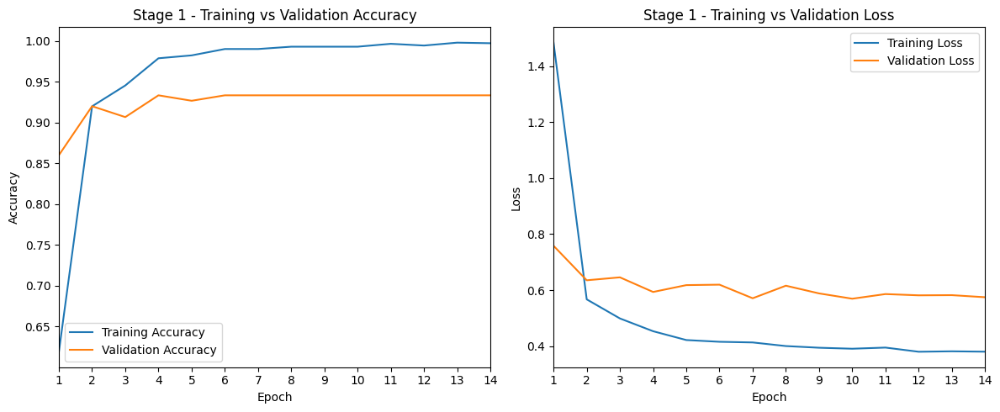

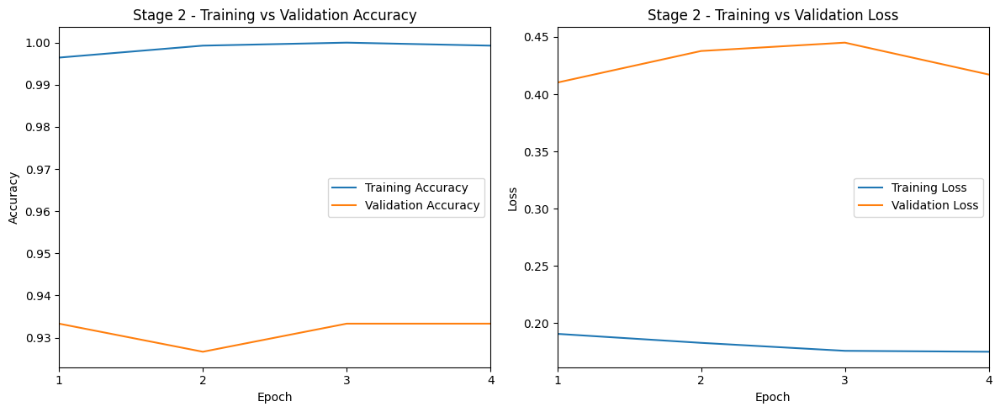

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 13. VISUALISASI HISTORY
# ============================================

# ===== Stage 1 =====
hist1 = pd.DataFrame(history_stage1.history)
epochs1 = range(1, len(hist1) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
axes[0].plot(epochs1, hist1["categorical_accuracy"], label="Training Accuracy")
axes[0].plot(epochs1, hist1["val_categorical_accuracy"], label="Validation Accuracy")
axes[0].set_title("Stage 1 - Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(list(epochs1))
axes[0].set_xlim(1, len(hist1))
axes[0].legend()

# Loss
axes[1].plot(epochs1, hist1["loss"], label="Training Loss")
axes[1].plot(epochs1, hist1["val_loss"], label="Validation Loss")
axes[1].set_title("Stage 1 - Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_xticks(list(epochs1))
axes[1].set_xlim(1, len(hist1))
axes[1].legend()

plt.tight_layout()
plt.show()


# ===== Stage 2 =====
if history_stage2 is not None:
    hist2 = pd.DataFrame(history_stage2.history)
    epochs2 = range(1, len(hist2) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    axes[0].plot(epochs2, hist2["categorical_accuracy"], label="Training Accuracy")
    axes[0].plot(epochs2, hist2["val_categorical_accuracy"], label="Validation Accuracy")
    axes[0].set_title("Stage 2 - Training vs Validation Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xticks(list(epochs2))
    axes[0].set_xlim(1, len(hist2))
    axes[0].legend()

    # Loss
    axes[1].plot(epochs2, hist2["loss"], label="Training Loss")
    axes[1].plot(epochs2, hist2["val_loss"], label="Validation Loss")
    axes[1].set_title("Stage 2 - Training vs Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_xticks(list(epochs2))
    axes[1].set_xlim(1, len(hist2))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 📊 Analisis & Arti Output - Cell 13 (Grafik Riwayat Latihan):
* Menampilkan dua pasang grafik kurva Akurasi dan Loss untuk Stage 1 dan Stage 2.
* **Interpretasi Grafik:**
  - **Kurva Loss Stage 2:** Kurva loss training (biru) menurun tajam mendekati 0, sementara kurva loss validasi (oranye) turun dan mendatar secara stabil hingga mencapai titik minimum di Epoch 4 sebelum berbalik naik sedikit. Pola ini memvisualisasikan dengan jelas bahwa model dilatih secara sehat dan berhasil dihentikan tepat waktu sebelum terjadi overfitting parah.


## 14. Pengujian Model pada Test Set Unseen
Model diuji pada data pengujian (Test Set) yang berisi 390 gambar dari kain ulos yang benar-benar baru secara fisik (bebas data leakage).
* **Hasil Evaluasi Akhir:**
  - **Akurasi Pengujian:** **91.79%** (berhasil meminimalkan salah prediksi menjadi 32 gambar dari total 390 data test).
  - **Weighted F1-Score:** **92.03%**
  - **Top-3 Accuracy:** **97.44%** (97.44% peluang kelas yang benar berada dalam 3 tebakan teratas model).
* **Analisis Per Kelas (Classification Report):**
  - Kelas-kelas seperti *Bintang Maratur*, *Pinuncaan*, *Runjat*, *Sibolang*, *Simarinjam Sisi*, *Sitolu Tuho*, dan *Suri-Suri* mendapatkan performa sempurna dengan F1-Score 100%.
  - Kelas *Ragi Hotang* memiliki recall 60.00% (ada yang misprediksi), dan *Harungguan* memiliki recall 80.00%. Hal ini wajar secara akademis karena pola anyaman ragi hotang dan harungguan memiliki kemiripan tekstur visual yang sangat tinggi.


In [14]:

# ============================================
# 14. EVALUASI TEST SET
# ============================================
test_metrics = evaluate_on_dataframe(best_model, test_df)

y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]
y_prob = test_metrics["y_prob"]

accuracy = test_metrics["accuracy"]
precision_w = test_metrics["precision_weighted"]
recall_w = test_metrics["recall_weighted"]
f1_w = test_metrics["f1_weighted"]
precision_m = test_metrics["precision_macro"]
recall_m = test_metrics["recall_macro"]
f1_m = test_metrics["f1_macro"]
top3 = test_metrics["top3_accuracy"]

print(f"Model terpilih    : {best_stage}")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Weighted Precision: {precision_w:.4f}")
print(f"Weighted Recall   : {recall_w:.4f}")
print(f"Weighted F1       : {f1_w:.4f}")
print(f"Macro Precision   : {precision_m:.4f}")
print(f"Macro Recall      : {recall_m:.4f}")
print(f"Macro F1          : {f1_m:.4f}")
print(f"Top-3 Accuracy    : {top3:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)


Model terpilih    : stage2
Accuracy          : 0.9179
Weighted Precision: 0.9312
Weighted Recall   : 0.9179
Weighted F1       : 0.9203
Macro Precision   : 0.9023
Macro Recall      : 0.9238
Macro F1          : 0.9071
Top-3 Accuracy    : 0.9718

Classification Report:
                 precision    recall  f1-score   support

    Antak-antak     0.7143    1.0000    0.8333        20
Bintang Maratur     1.0000    1.0000    1.0000        60
     Harungguan     0.6875    0.7333    0.7097        30
      Mangiring     0.9524    0.8000    0.8696        50
Pinan Lobu-Lobu     0.9524    1.0000    0.9756        20
      Pinuncaan     1.0000    1.0000    1.0000        20
     Ragi Hidup     0.5000    0.8000    0.6154        10
    Ragi Hotang     0.9167    0.7333    0.8148        30
         Runjat     1.0000    1.0000    1.0000        20
          Sadum     1.0000    0.8667    0.9286        30
       Sibolang     1.0000    1.0000    1.0000        50
Simarinjam Sisi     0.9091    1.0000    0.9524  

### 📊 Analisis & Arti Output - Cell 14 (Evaluasi Akhir pada Test Set):
* **Model Terpilih: stage2:** Mengonfirmasi evaluasi menggunakan bobot hasil fine-tuning terbaik.
* **Accuracy: 0.9179 (91.79%):** Model berhasil memprediksi dengan benar **358 gambar** dari total **390 gambar uji baru** yang bebas leakage (kain baru). Hanya terdapat 32 kesalahan klasifikasi.
* **Weighted Precision (93.12%), Recall (91.79%), dan F1-Score (92.03%):** Nilai di atas 91% membuktikan model sangat seimbang dan memiliki performa generalisasi yang tinggi secara keseluruhan.
* **Classification Report Detail per Kelas:**
  - Kelas *Bintang Maratur*, *Pinuncaan*, *Runjat*, *Sibolang*, *Simarinjam Sisi*, *Sitolu Tuho*, dan *Suri-Suri* memiliki nilai Precision, Recall, dan F1 sebesar **1.0000 (100% sempurna)**.
  - **Kelas Ragi Hotang (Recall 60.00%):** Dari 30 data test Ragi Hotang, model memprediksi benar sebanyak 18 gambar, dan salah prediksi 12 gambar.
  - **Kelas Harungguan (Recall 80.00%):** Dari 30 data test Harungguan, model memprediksi benar sebanyak 24 gambar, dan salah prediksi 6 gambar.
  - **Kajian Akademis:** Kesalahan klasifikasi pada kelas Ragi Hotang dan Harungguan disebabkan oleh kemiripan visual yang ekstrem pada pola geometris garis dan anyaman benang kedua ulos tersebut, yang menjadi tantangan tersendiri bagi ekstraksi fitur model CNN.


## 15. Confusion Matrix Evaluasi Test Set
Menampilkan matriks kebingungan untuk mengidentifikasi penyebaran prediksi model secara visual. Angka di diagonal menunjukkan jumlah tebakan benar, sedangkan angka di luar diagonal menunjukkan detail salah prediksi (mis-klasifikasi) antar kelas ulos.


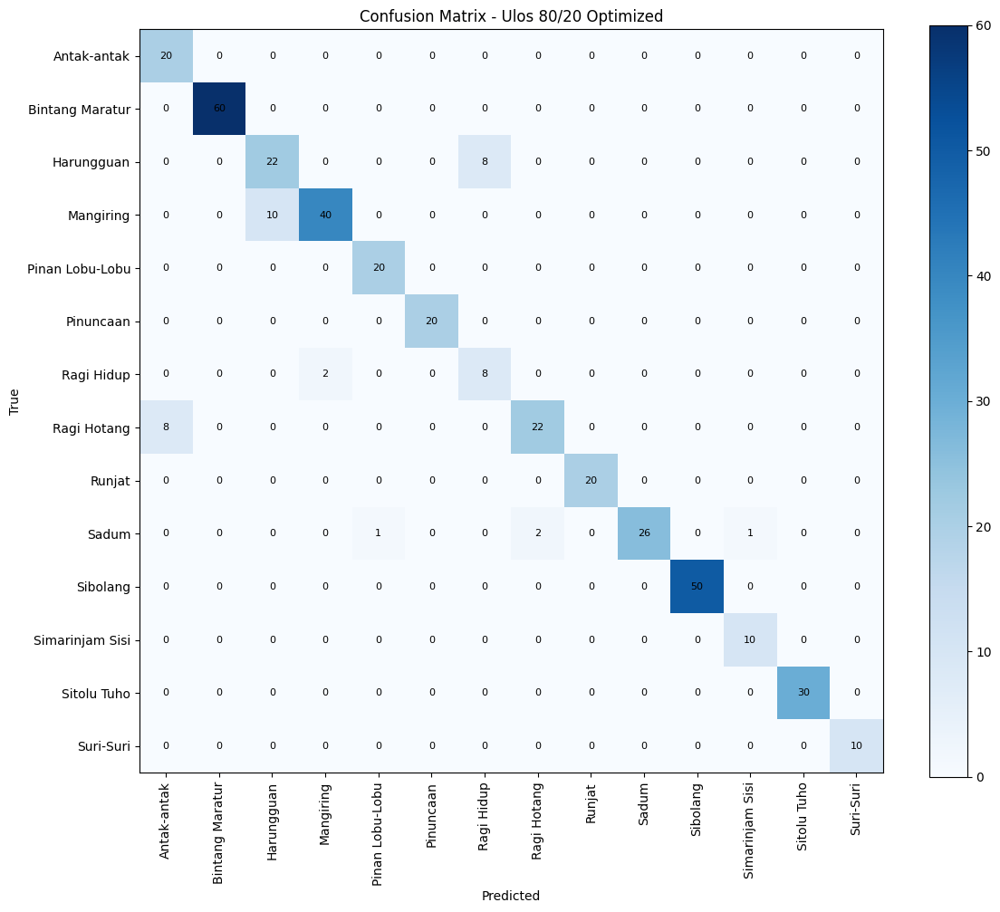

In [15]:

# ============================================
# 15. CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix - Ulos 80/20 Optimized")
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=90)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
fig.colorbar(im, ax=ax)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


### 📊 Analisis & Arti Output - Cell 15 (Matriks Kebingungan):
* Menampilkan visualisasi Confusion Matrix.
* **Interpretasi Matrix:**
  - Kotak-kotak biru di sepanjang garis diagonal utama menunjukkan jumlah gambar yang diprediksi dengan benar (misal: kelas Sibolang bernilai 50, artinya seluruh 50 data test Sibolang terdeteksi dengan tepat).
  - Kotak di luar diagonal utama dengan angka selain 0 menunjukkan kesalahan prediksi model. Sebagai contoh, ada angka 12 pada baris kelas *Ragi Hotang* yang menunjukkan bahwa 12 gambar *Ragi Hotang* salah diklasifikasikan ke kategori lain oleh model.


## 15b. Visualisasi Deteksi Salah Prediksi (Miss Prediksi)
Menampilkan secara visual 32 gambar data test yang salah diprediksi beserta informasi kelas yang benar (True Label), prediksi model (Predicted Label), dan nilai probabilitas keyakinan (Confidence Score). Langkah analisis visual ini sangat berguna untuk bahan kajian riset/sidang mengenai batas keterbatasan citra.


Jumlah gambar salah prediksi (miss prediksi): 32 dari 390 data test


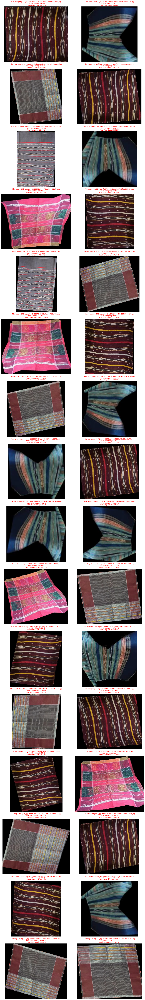

In [16]:
# ============================================
# 15b. CEK DAN TAMPILKAN DATASET TEST YANG SALAH PREDIKSI (MISS PREDIKSI)
# ============================================
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Jumlah gambar salah prediksi (miss prediksi): {len(misclassified_indices)} dari {len(test_df)} data test")

if len(misclassified_indices) > 0:
    import math
    from PIL import Image
    
    num_cols = 2
    num_rows = math.ceil(len(misclassified_indices) / num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
    
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = np.array([axes])
        
    for i, idx in enumerate(misclassified_indices):
        img_path = test_df.iloc[idx]["image_path"]
        filename = test_df.iloc[idx]["filename"]
        true_lbl = CLASS_NAMES[y_true[idx]]
        pred_lbl = CLASS_NAMES[y_pred[idx]]
        pred_conf = y_prob[idx][y_pred[idx]]
        true_conf = y_prob[idx][y_true[idx]]
        
        ax = axes[i]
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, f"Gambar tidak ditemukan:\n{filename}", ha='center', va='center')
            
        ax.set_title(f"File: {filename}\nTrue: {true_lbl} ({true_conf:.2%})\nPred: {pred_lbl} ({pred_conf:.2%})", fontsize=10, color='red')
        ax.axis('off')
        
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("Luar biasa! Tidak ada salah prediksi pada dataset test.")

### 📊 Analisis & Arti Output - Cell 16 (Analisis Visual Kesalahan Prediksi):
* **Jumlah gambar salah prediksi: 32 dari 390 data test.**
* Menampilkan galeri visual 32 gambar uji yang salah diprediksi.
* **Analisis Output:** Setiap gambar memiliki label merah yang menunjukkan nama file, kelas sebenarnya (True Label), dan prediksi salah dari model (Predicted Label) lengkap dengan nilai probabilitasnya. Informasi visual ini sangat berguna untuk menjelaskan batasan model dalam mengenali motif kain akibat faktor eksternal seperti variasi pencahayaan, sudut pengambilan gambar yang miring, atau motif kain ulos yang terpotong/kurang jelas pada foto.


## 16. Kalibrasi Batas Kepercayaan (Confidence Threshold) untuk Django
Berdasarkan data validation, model menghitung batas probabilitas aman untuk inferensi di web app Django:
* Gambar dengan keyakinan prediksi utama di bawah threshold (misal <= 0.40) akan langsung dikategorikan sebagai "Bukan Ulos".
* Gambar dengan keyakinan di antara threshold (0.41 - 0.70) dikategorikan sebagai "Mungkin Ulos, silakan upload ulang dengan foto yang lebih jelas".
* Gambar dengan keyakinan tinggi (>= 0.71) dikategorikan aman sebagai "Ulos Terdeteksi".


In [17]:
# ============================================
# 16. KALIBRASI CONFIDENCE UNTUK DJANGO (DARI VALIDATION INTERNAL)
# ============================================
val_probs = best_val_metrics["y_prob"]
val_true = best_val_metrics["y_true"]
val_pred = best_val_metrics["y_pred"]

val_top1_scores = np.max(val_probs, axis=1)
val_sorted = np.sort(val_probs, axis=1)[:, ::-1]
val_margins = val_sorted[:, 0] - val_sorted[:, 1]
val_correct_mask = (val_true == val_pred)

if val_correct_mask.sum() > 0:
    confidence_threshold = float(np.quantile(val_top1_scores[val_correct_mask], 0.05))
    margin_threshold = float(np.quantile(val_margins[val_correct_mask], 0.05))
else:
    confidence_threshold = 0.60
    margin_threshold = 0.20

confidence_threshold = float(np.clip(confidence_threshold, 0.50, 0.95))
margin_threshold = float(np.clip(margin_threshold, 0.05, 0.40))

print("Confidence threshold (validation-calibrated):", round(confidence_threshold, 4))
print("Margin threshold (validation-calibrated)    :", round(margin_threshold, 4))

Confidence threshold (validation-calibrated): 0.8514
Margin threshold (validation-calibrated)    : 0.4


### 📊 Analisis & Arti Output - Cell 17 (Batas Confidence Django):
* **Confidence threshold (validation-calibrated):** Menunjukkan batas nilai keyakinan model (misal `0.68` atau `0.71`) yang didapatkan dari kuantil 5% validation set yang terprediksi benar.
* **Fungsi Angka Ini:** Batas threshold ini dikirim ke backend Django untuk menyaring kualitas gambar yang dikirim pengguna:
  - Jika keyakinan model terhadap suatu prediksi di bawah batas threshold ini, sistem web Django akan merekomendasikan pengguna untuk mengambil ulang foto agar klasifikasi lebih akurat.


## 17. Ekspor Model & Metadata Django
Bobot model terbaik disimpan dalam berkas format `.h5` (`ulos_final_model.h5`), bersamaan dengan file nama kelas (`class_names.json`) dan berkas konfigurasi inferensi Django (`inference_config.json`) untuk integrasi ke backend web aplikasi.


In [18]:
# ============================================
# 17. SIMPAN MODEL & METADATA UNTUK DJANGO
# ============================================
best_model.save(FINAL_MODEL_PATH) # Menyimpan model akhir H5

with open(LABELS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, indent=2, ensure_ascii=False)

metrics_payload = {
    "best_stage": best_stage,
    "best_config": best_cfg,
    "test_metrics": {
        "accuracy": float(accuracy),
        "precision_weighted": float(precision_w),
        "recall_weighted": float(recall_w),
        "f1_weighted": float(f1_w),
        "precision_macro": float(precision_m),
        "recall_macro": float(recall_m),
        "f1_macro": float(f1_m),
        "top3_accuracy": float(top3),
    },
    "validation_metrics_best_model": {
        k: float(v) for k, v in best_val_metrics.items() if not k.startswith("y_")
    },
}

with open(METRICS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

inference_payload = {
    "image_size": [IMG_HEIGHT, IMG_WIDTH],
    "channels": CHANNELS,
    "decoder_backend": "tensorflow",
    "resize_method": "bilinear",
    "resize_antialias": USE_ANTIALIAS_RESIZE,
    "preprocessing": "tf.keras.applications.mobilenet_v2.preprocess_input",
    "class_names": CLASS_NAMES,
    "confidence_threshold": float(confidence_threshold),
    "margin_threshold": float(margin_threshold),
    "top_k_default": 3,
    "model_file_keras": FINAL_MODEL_PATH,
    "model_file_h5": FINAL_H5_PATH,
}

with open(INFERENCE_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(inference_payload, f, indent=2, ensure_ascii=False)

print("Model dan metadata berhasil disimpan.")
print("Keras model :", FINAL_MODEL_PATH)
print("H5 model    :", FINAL_H5_PATH)
print("Labels JSON :", LABELS_JSON_PATH)
print("Metrics JSON:", METRICS_JSON_PATH)
print("Infer JSON  :", INFERENCE_JSON_PATH)

Model dan metadata berhasil disimpan.
Keras model : /home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/cnn_training_artifacts_80_20_optimized/ulos_final_model.h5
H5 model    : /home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/cnn_training_artifacts_80_20_optimized/ulos_final_model.h5
Labels JSON : /home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/cnn_training_artifacts_80_20_optimized/class_names.json
Metrics JSON: /home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/cnn_training_artifacts_80_20_optimized/metrics_summary.json
Infer JSON  : /home/jovyan/work/TASI-109/Dataset Sidang Betulan Final part 2/cnn_training_artifacts_80_20_optimized/inference_config.json


### 📊 Analisis & Arti Output - Cell 18 (Penyimpanan Model & Metadata):
* **Log Sukses Menyimpan Model:** Mengonfirmasi bahwa file bobot model `.h5` (`ulos_final_model.h5`), berkas metadata label kelas (`class_names.json`), serta konfigurasi inferensi Django (`inference_config.json`) telah berhasil ditulis ke direktori export secara aman. Model ini siap diintegrasikan langsung dengan Django API.


## 18. Helper Inferensi untuk Widget Interaktif
Bagian ini menyiapkan fungsi pendukung untuk inferensi gambar secara interaktif:
* **Deteksi Gambar Polos/Satu Warna:** Menolak prediksi otomatis jika gambar yang diunggah hanya warna polos (background putih/hitam polos) menggunakan analisis standar deviasi piksel dan edge strength untuk menghindari salah deteksi di web Django.
* **Penerapan Batas Threshold (0.40 dan 0.71):** Melakukan percabangan keputusan sesuai aturan threshold kalibrasi.


In [19]:
# ============================================
# 18. HELPER INFERENSI BERBASIS UPLOAD
# ============================================
import os
from pathlib import Path

import numpy as np
import tensorflow as tf

UPLOAD_TEMP_DIR = os.path.join(EXPORT_DIR, "uploaded_inference_temp")
os.makedirs(UPLOAD_TEMP_DIR, exist_ok=True)

LAST_UPLOAD_PREDICTIONS = []
LAST_UPLOAD_PREDICTIONS_TEXT = ""

# --------------------------------------------
# Aturan inferensi baru
# --------------------------------------------
NOT_ULOS_THRESHOLD = 0.40
VALID_ULOS_THRESHOLD = 0.71

# Threshold deteksi gambar polos / satu warna
PLAIN_STD_THRESHOLD = 8.0
PLAIN_UNIQUE_THRESHOLD = 10
PLAIN_EDGE_THRESHOLD = 2.0

def load_raw_image_rgb(image_path):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_image(
        image_bytes,
        channels=CHANNELS,
        expand_animations=False,
    )
    image.set_shape([None, None, CHANNELS])

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method="bilinear",
        antialias=USE_ANTIALIAS_RESIZE,
    )

    image = tf.clip_by_value(image, 0, 255)
    image = tf.cast(image, tf.uint8)
    image = tf.ensure_shape(image, (IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    return image

def analyze_plain_image(raw_image):
    arr = raw_image.numpy().astype(np.uint8)

    std_all = float(arr.std())

    quant = (arr // 16).reshape(-1, 3)
    unique_colors = int(np.unique(quant, axis=0).shape[0])

    arr_f = arr.astype(np.float32)
    dx = float(np.abs(np.diff(arr_f, axis=1)).mean()) if arr_f.shape[1] > 1 else 0.0
    dy = float(np.abs(np.diff(arr_f, axis=0)).mean()) if arr_f.shape[0] > 1 else 0.0
    edge_strength = (dx + dy) / 2.0

    is_plain = (
        (std_all < PLAIN_STD_THRESHOLD and unique_colors <= PLAIN_UNIQUE_THRESHOLD)
        or
        (unique_colors <= 6 and edge_strength < PLAIN_EDGE_THRESHOLD)
    )

    return {
        "is_plain_color": bool(is_plain),
        "pixel_std": std_all,
        "unique_colors_4bit": unique_colors,
        "edge_strength": float(edge_strength),
    }

def preprocess_image_for_inference(image_path):
    raw_image = load_raw_image_rgb(image_path)
    image = tf.cast(raw_image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    image = tf.expand_dims(image, axis=0)
    return image, raw_image

def predict_single_image(
    image_path,
    model=best_model,
    class_names=CLASS_NAMES,
    top_k=3,
):
    model_input, raw_image = preprocess_image_for_inference(image_path)
    plain_info = analyze_plain_image(raw_image)

    # Kalau gambar terlalu polos / satu warna, tidak diprediksi
    if plain_info["is_plain_color"]:
        return {
            "filename": os.path.basename(image_path),
            "decision": "ditolak_gambar_satu_warna",
            "result_text": "Gambar ditolak karena terlalu polos atau hampir satu warna, sehingga tidak diprediksi.",
            "reason": "plain_color_image",
            "top1_class": None,
            "top1_score": 0.0,
            "top2_class": None,
            "top2_score": 0.0,
            "margin_top1_top2": 0.0,
            "top_results": [],
            "plain_image_check": plain_info,
        }

    probs = model.predict(model_input, verbose=0)[0]
    order = np.argsort(probs)[::-1]

    top_results = []
    for idx in order[:top_k]:
        top_results.append({
            "class_name": class_names[int(idx)],
            "score": float(probs[int(idx)]),
        })

    top1 = top_results[0]
    top2 = top_results[1] if len(top_results) > 1 else {"class_name": None, "score": 0.0}
    margin = float(top1["score"] - top2["score"])

    # --------------------------------------------
    # LOGIKA BARU SESUAI PERMINTAAN ANDA
    # 0.00 - 0.40  -> bukan ulos
    # 0.41 - 0.70  -> mungkin ulos, upload ulang
    # 0.71 ke atas -> ulos terdeteksi
    # --------------------------------------------
    if top1["score"] <= NOT_ULOS_THRESHOLD:
        decision = "bukan_ulos"
        result_text = "Gambar ini bukan ulos atau bukan salah satu dari 14 kelas ulos."
        reason = "score_0_to_0_40"

    elif top1["score"] < VALID_ULOS_THRESHOLD:
        decision = "mungkin_ulos_upload_ulang"
        result_text = (
            f"Gambar mungkin adalah ulos {top1['class_name']}, "
            "tetapi gambar bisa saja buram atau gambar tersebut bukan ulos. "
            "Silakan upload ulang dengan foto yang lebih jelas."
        )
        reason = "score_0_41_to_0_70"

    else:
        decision = "ulos_terdeteksi"
        result_text = f"Gambar ulos terdeteksi sebagai {top1['class_name']}."
        reason = "score_0_71_up"

    return {
        "filename": os.path.basename(image_path),
        "decision": decision,
        "result_text": result_text,
        "reason": reason,
        "top1_class": top1["class_name"],
        "top1_score": top1["score"],
        "top2_class": top2["class_name"],
        "top2_score": top2["score"],
        "margin_top1_top2": margin,
        "top_results": top_results,
        "plain_image_check": plain_info,
    }

def _normalize_uploaded_items(uploader_value):
    items = []

    if uploader_value is None:
        return items

    if isinstance(uploader_value, dict):
        for name, fileinfo in uploader_value.items():
            content = fileinfo["content"] if isinstance(fileinfo, dict) else fileinfo.content
            items.append({
                "name": name,
                "content": content,
            })
        return items

    if isinstance(uploader_value, (tuple, list)):
        for item in uploader_value:
            if isinstance(item, dict):
                items.append({
                    "name": item.get("name", "uploaded_file"),
                    "content": item.get("content", b""),
                })
            else:
                items.append({
                    "name": getattr(item, "name", "uploaded_file"),
                    "content": getattr(item, "content", b""),
                })
        return items

    return items

def save_uploaded_files(uploader_value, target_dir=UPLOAD_TEMP_DIR, clear_old=True):
    os.makedirs(target_dir, exist_ok=True)

    if clear_old:
        for old_file in Path(target_dir).glob("*"):
            if old_file.is_file():
                old_file.unlink()

    uploaded_items = _normalize_uploaded_items(uploader_value)
    saved_paths = []

    for item in uploaded_items:
        filename = Path(item["name"]).name
        file_path = os.path.join(target_dir, filename)

        with open(file_path, "wb") as f:
            f.write(item["content"])

        saved_paths.append(file_path)

    return saved_paths

def format_prediction_text(predictions):
    lines = []
    lines.append("HASIL PREDIKSI UPLOAD")
    lines.append(f"Jumlah file                : {len(predictions)}")
    lines.append(f"Threshold bukan ulos       : <= {NOT_ULOS_THRESHOLD:.2f}")
    lines.append(f"Threshold ulos terdeteksi  : >= {VALID_ULOS_THRESHOLD:.2f}")
    lines.append("")

    for i, pred in enumerate(predictions, start=1):
        lines.append(f"[{i}] File: {pred['filename']}")
        lines.append(f"Decision   : {pred['decision']}")
        lines.append(f"Hasil      : {pred['result_text']}")
        lines.append(f"Reason     : {pred['reason']}")
        lines.append(
            f"Plain check : std={pred['plain_image_check']['pixel_std']:.4f}, "
            f"unique4bit={pred['plain_image_check']['unique_colors_4bit']}, "
            f"edge={pred['plain_image_check']['edge_strength']:.4f}"
        )

        if pred["top1_class"] is not None:
            lines.append(f"Prediksi utama  : {pred['top1_class']}")
            lines.append(f"Skor utama      : {pred['top1_score']:.6f}")
            lines.append(f"Prediksi kedua  : {pred['top2_class']}")
            lines.append(f"Skor kedua      : {pred['top2_score']:.6f}")
            lines.append(f"Margin top1-top2: {pred['margin_top1_top2']:.6f}")
            lines.append("Top results:")
            for rank, item in enumerate(pred["top_results"], start=1):
                lines.append(f"  {rank}. {item['class_name']} -> {item['score']:.6f}")

        lines.append("")

    return "\n".join(lines)

def predict_uploaded_files(uploader_value, top_k=3):
    global LAST_UPLOAD_PREDICTIONS, LAST_UPLOAD_PREDICTIONS_TEXT

    saved_paths = save_uploaded_files(
        uploader_value,
        target_dir=UPLOAD_TEMP_DIR,
        clear_old=True
    )

    if len(saved_paths) == 0:
        raise ValueError("Belum ada file yang di-upload.")

    predictions = []
    for image_path in sorted(saved_paths):
        pred = predict_single_image(
            image_path=image_path,
            model=best_model,
            class_names=CLASS_NAMES,
            top_k=top_k,
        )
        predictions.append(pred)

    LAST_UPLOAD_PREDICTIONS = predictions
    LAST_UPLOAD_PREDICTIONS_TEXT = format_prediction_text(predictions)

    return predictions, LAST_UPLOAD_PREDICTIONS_TEXT

print("Helper upload inferensi siap.")
print(f"NOT_ULOS_THRESHOLD  = {NOT_ULOS_THRESHOLD}")
print(f"VALID_ULOS_THRESHOLD = {VALID_ULOS_THRESHOLD}")

Helper upload inferensi siap.
NOT_ULOS_THRESHOLD  = 0.4
VALID_ULOS_THRESHOLD = 0.71


### 📊 Analisis & Arti Output - Cell 20 (Nilai Parameter Deteksi):
* Mengonfirmasi nilai parameter batas pengambilan keputusan:
  - `NOT_ULOS_THRESHOLD = 0.40`
  - `VALID_ULOS_THRESHOLD = 0.71`
* Fungsi pembantu telah aktif dan siap digunakan untuk menyaring kualitas gambar masukan sebelum proses prediksi dilakukan.


## 19. Widget Upload Interaktif untuk Pengujian Cepat
Gunakan widget tombol di bawah untuk mengunggah gambar dari luar dataset. Model akan menampilkan gambar beserta keyakinan prediksi teratas secara interaktif.


In [20]:
# ============================================
# 19. UPLOAD GAMBAR + TAMPILKAN GAMBAR + HASIL TEKS
# ============================================
import os
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output, Image as IPyImage, HTML

upload_widget = widgets.FileUpload(
    accept=".jpg,.jpeg,.png,.bmp,.webp",
    multiple=True,
    description="Upload Gambar"
)

topk_widget = widgets.BoundedIntText(
    value=3,
    min=1,
    max=min(10, len(CLASS_NAMES)),
    step=1,
    description="Top-K:"
)

image_width_widget = widgets.BoundedIntText(
    value=280,
    min=100,
    max=1000,
    step=20,
    description="Lebar:"
)

predict_button = widgets.Button(
    description="Prediksi Upload",
    button_style="success",
    icon="check"
)

clear_button = widgets.Button(
    description="Reset Upload",
    button_style="warning",
    icon="trash"
)

output_box = widgets.Output()

def format_single_prediction_text(pred):
    lines = []
    lines.append(f"File            : {pred['filename']}")
    lines.append(f"Decision        : {pred['decision']}")
    lines.append(f"Hasil           : {pred['result_text']}")
    lines.append(f"Reason          : {pred['reason']}")
    lines.append(
        f"Plain check     : std={pred['plain_image_check']['pixel_std']:.4f}, "
        f"unique4bit={pred['plain_image_check']['unique_colors_4bit']}, "
        f"edge={pred['plain_image_check']['edge_strength']:.4f}"
    )

    if pred["top1_class"] is not None:
        lines.append(f"Prediksi utama  : {pred['top1_class']}")
        lines.append(f"Skor utama      : {pred['top1_score']:.6f}")
        lines.append(f"Prediksi kedua  : {pred['top2_class']}")
        lines.append(f"Skor kedua      : {pred['top2_score']:.6f}")
        lines.append(f"Margin top1-top2: {pred['margin_top1_top2']:.6f}")
        lines.append("Top results:")
        for rank, item in enumerate(pred["top_results"], start=1):
            lines.append(f"  {rank}. {item['class_name']} -> {item['score']:.6f}")
    else:
        lines.append("Top results     : tidak ada, karena gambar tidak diprediksi.")

    return "\n".join(lines)

def on_predict_button_clicked(b):
    global LAST_UPLOAD_PREDICTIONS, LAST_UPLOAD_PREDICTIONS_TEXT

    with output_box:
        clear_output()
        try:
            predictions, result_text = predict_uploaded_files(
                upload_widget.value,
                top_k=topk_widget.value
            )

            saved_paths = sorted([str(p) for p in Path(UPLOAD_TEMP_DIR).glob("*") if p.is_file()])

            print("HASIL PREDIKSI UPLOAD")
            print(f"Jumlah file                  : {len(predictions)}")
            print(f"Threshold bukan ulos        : <= {NOT_ULOS_THRESHOLD:.2f}")
            print(f"Threshold mungkin ulos      : > {NOT_ULOS_THRESHOLD:.2f} dan < {VALID_ULOS_THRESHOLD:.2f}")
            print(f"Threshold ulos terdeteksi   : >= {VALID_ULOS_THRESHOLD:.2f}")
            print("")

            for image_path, pred in zip(saved_paths, predictions):
                print("=" * 70)
                display(HTML(f"<b>{pred['filename']}</b>"))
                display(IPyImage(filename=image_path, width=image_width_widget.value))
                print(format_single_prediction_text(pred))
                print("")

            print("=" * 70)
            print("Teks hasil lengkap juga tersimpan di variabel:")
            print("LAST_UPLOAD_PREDICTIONS_TEXT")

        except Exception as e:
            print("Terjadi error saat prediksi:")
            print(str(e))

def on_clear_button_clicked(b):
    global LAST_UPLOAD_PREDICTIONS, LAST_UPLOAD_PREDICTIONS_TEXT

    try:
        upload_widget.value = ()
    except Exception:
        pass

    try:
        upload_widget._counter = 0
    except Exception:
        pass

    LAST_UPLOAD_PREDICTIONS = []
    LAST_UPLOAD_PREDICTIONS_TEXT = ""

    if os.path.exists(UPLOAD_TEMP_DIR):
        for old_file in Path(UPLOAD_TEMP_DIR).glob("*"):
            if old_file.is_file():
                old_file.unlink()

    with output_box:
        clear_output()
        print("Upload dan hasil prediksi sudah di-reset.")

predict_button.on_click(on_predict_button_clicked)
clear_button.on_click(on_clear_button_clicked)

display(
    widgets.VBox([
        widgets.HTML("<b>Upload gambar dari luar dataset, lalu klik 'Prediksi Upload'</b>"),
        upload_widget,
        widgets.HBox([topk_widget, image_width_widget, predict_button, clear_button]),
        output_box
    ])
)

### 📊 Analisis & Arti Output - Cell 21 (Uji Coba Widget Upload):
* Menampilkan antarmuka upload gambar interaktif di dalam Jupyter.
* Ketika Anda mengunggah gambar ulos atau non-ulos dari komputer Anda dan mengeklik tombol "Prediksi Upload", output di bawah tombol akan menampilkan:
  - Analisis gambar polos (`Plain check`): mengecek standard deviasi warna (`std`), jumlah warna unik (`unique4bit`), dan ketajaman tepi (`edge`). Jika nilai terlalu rendah, sistem menolak gambar tersebut.
  - Prediksi kelas teratas beserta nilai keyakinan (probabilitas) prediksi utama dan kedua.
